# Regime Diagnostic for MS-VECM Generator (β-switching framing)

Regimes are **structural** states defined by the cointegration coefficient itself. Each regime $r$ has its own $(\alpha_r, \beta_r, \sigma_r)$ in the model

$$s_{1,t} = \alpha_r + \beta_r\, s_{2,t} + u_{r,t}, \qquad u_{r,t} = \phi\, u_{r,t-1} + \varepsilon_t,\ \varepsilon_t \sim \mathcal{N}(0, \sigma_r^2)$$

with $\phi$ shared across regimes (post-fit on the residual). Within-regime $\beta$ is held constant — by assumption, β shifts *between* regimes, not within them.

**Pipeline**

1. Johansen on the full sample → reference $\beta_{\mathrm{global}}$ (kept for fallback / comparison).
2. Stationarity sanity checks on the Johansen spread.
3. Rolling-OLS β + histogram + k-means seed (does β look multi-modal?).
4. Single-regime baseline: OLS of $s_1$ on $s_2$, AR(1) on residuals.
5. **Constant-β simulation — artefact baseline for rolling β** (does the multimodality survive when the true β is fixed?).

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

np.random.seed(9823)
plt.rcParams['figure.figsize'] = (12, 4)

In [15]:
# Same pair as data.ipynb: PSX (Phillips 66) and MPC (Marathon Petroleum).
# Convention here: s1 = log PSX (dependent), s2 = log MPC (regressor).
ticker_1 = 'PSX'
ticker_2 = 'MPC'

df1 = yf.Ticker(ticker_1).history(period='40y')
df2 = yf.Ticker(ticker_2).history(period='40y')

common = df1.index.intersection(df2.index)
df1 = df1.loc[common].iloc[-3500:]
df2 = df2.loc[common].iloc[-3500:]

s1 = np.log(df1['Close'].values)
s2 = np.log(df2['Close'].values)

print(f'{len(s1)} aligned daily observations from {df1.index[0].date()} to {df1.index[-1].date()}')

3500 aligned daily observations from 2012-06-08 to 2026-05-11


## 1. Johansen — reference $\beta_{\mathrm{global}}$

Trace statistic vs critical values [90%, 95%, 99%]:
  H0: rank <= 0: stat =  17.324, cv = [13.4294 15.4943 19.9349]
  H0: rank <= 1: stat =   0.327, cv = [2.7055 3.8415 6.6349]

Global beta (Johansen): 0.5268


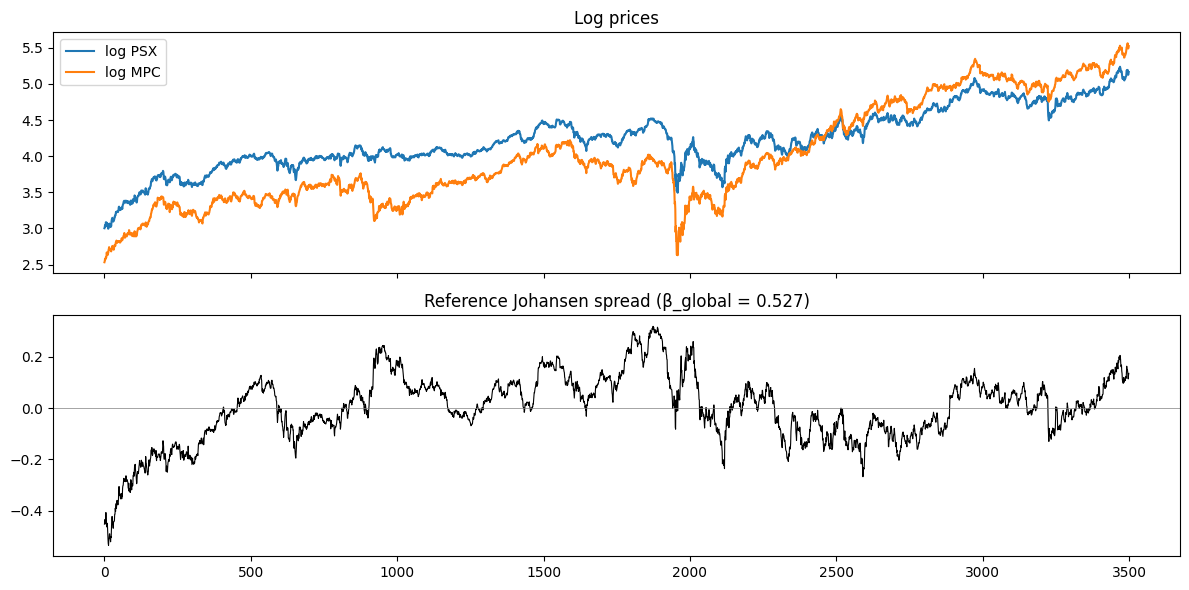

In [16]:
Y = np.column_stack([s1, s2])
joh = coint_johansen(Y, det_order=0, k_ar_diff=1)

print('Trace statistic vs critical values [90%, 95%, 99%]:')
for r, (stat, cv) in enumerate(zip(joh.lr1, joh.cvt)):
    print(f'  H0: rank <= {r}: stat = {stat:7.3f}, cv = {cv}')

v = joh.evec[:, 0]; v = v / v[0]
beta_global = -v[1]
print(f'\nGlobal beta (Johansen): {beta_global:.4f}')

spread_global = s1 - beta_global * s2
spread_global = spread_global - spread_global.mean()

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(s1, label=f'log {ticker_1}'); ax[0].plot(s2, label=f'log {ticker_2}')
ax[0].legend(); ax[0].set_title('Log prices')
ax[1].plot(spread_global, color='black', lw=0.8); ax[1].axhline(0, color='grey', lw=0.5)
ax[1].set_title(f'Reference Johansen spread (β_global = {beta_global:.3f})')
plt.tight_layout(); plt.show()

## 2. Stationarity sanity on the Johansen spread

In [17]:
adf_stat, adf_p, *_ = adfuller(spread_global, autolag='AIC')
print(f'ADF:  stat = {adf_stat:7.3f}, p = {adf_p:.4f}   (reject unit root at 5% if p < 0.05)')
kpss_stat, kpss_p, *_ = kpss(spread_global, regression='c', nlags='auto')
print(f'KPSS: stat = {kpss_stat:7.3f}, p = {kpss_p:.4f}   (fail to reject stationarity at 5% if p > 0.05)')

ADF:  stat =  -3.970, p = 0.0016   (reject unit root at 5% if p < 0.05)
KPSS: stat =   1.191, p = 0.0100   (fail to reject stationarity at 5% if p > 0.05)


## 3. Rolling-OLS β + k-means seed

Rolling β:  mean=0.6024, std=0.2770, range=[0.0015, 1.1551]
Johansen β: 0.5268


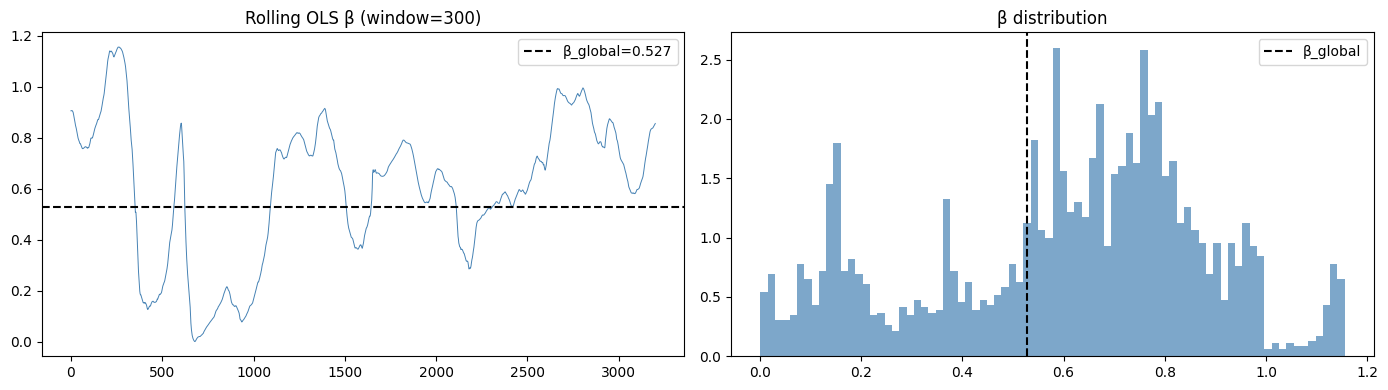

k=2 cluster centres: [np.float64(0.2361), np.float64(0.7511)]
k=3 cluster centres: [np.float64(0.1942), np.float64(0.6019), np.float64(0.8689)]


In [18]:
window_size = 300
betas_rolling = np.array([
    np.polyfit(s2[i:i+window_size], s1[i:i+window_size], 1)[0]
    for i in range(len(s1) - window_size + 1)
])

print(f'Rolling β:  mean={betas_rolling.mean():.4f}, std={betas_rolling.std():.4f}, '
      f'range=[{betas_rolling.min():.4f}, {betas_rolling.max():.4f}]')
print(f'Johansen β: {beta_global:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(betas_rolling, lw=0.7, color='steelblue')
ax[0].axhline(beta_global, color='k', ls='--', label=f'β_global={beta_global:.3f}')
ax[0].set_title(f'Rolling OLS β (window={window_size})'); ax[0].legend()
ax[1].hist(betas_rolling, bins=80, density=True, alpha=0.7, color='steelblue')
ax[1].axvline(beta_global, color='k', ls='--', label=f'β_global')
ax[1].set_title('β distribution'); ax[1].legend()
plt.tight_layout(); plt.show()

beta_2d = betas_rolling.reshape(-1, 1)
km2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(beta_2d)
km3 = KMeans(n_clusters=3, n_init=10, random_state=42).fit(beta_2d)
print(f'k=2 cluster centres: {[round(b, 4) for b in sorted(km2.cluster_centers_.flatten())]}')
print(f'k=3 cluster centres: {[round(b, 4) for b in sorted(km3.cluster_centers_.flatten())]}')

### Observations

We notice that the hedge ratio does not follow a strict unimodal normal distribution here (centered around the mean \beta). Instead, looking at the distribution and the rolling OLS we see that there is some clustering around \beta = 0.15, hinting at a potentially multimodal distribution / differing regimes based on betas.

This could be due to the low amount of data points available (3500) however, as beta might converge to a normal distribution with more data, with the fluctuations we see becoming noise. To assess whether this might be the case, we should test what a distribution with a constant hedge ratio assumption would look like.


## 4. Single-regime baseline

In [19]:
exog_full = sm.add_constant(s2)
ols_res = sm.OLS(s1, exog_full).fit()
alpha_full = ols_res.params[0]
beta_full  = ols_res.params[1]
sigma_full = np.sqrt(ols_res.scale)
ll_baseline = ols_res.llf
u_full = ols_res.resid

ar1_baseline = AutoReg(u_full, lags=1, old_names=False).fit()
phi_baseline = ar1_baseline.params[1]
hl_baseline  = np.log(2)/(-np.log(abs(phi_baseline))) if 0 < abs(phi_baseline) < 1 else np.inf

print(f'Single-regime baseline:')
print(f'  alpha = {alpha_full:.4f}')
print(f'  beta  = {beta_full:.4f}')
print(f'  sigma_uncond (residual)   = {sigma_full:.4f}')
print(f'  phi  (post-fit AR(1))     = {phi_baseline:.4f},  half-life = {hl_baseline:.1f} days')
print(f'  LL of s1|s2 (iid)         = {ll_baseline:.2f}')

Single-regime baseline:
  alpha = 1.9733
  beta  = 0.5636
  sigma_uncond (residual)   = 0.1277
  phi  (post-fit AR(1))     = 0.9935,  half-life = 105.8 days
  LL of s1|s2 (iid)         = 2236.71


## 5. Constant-β simulation — artefact baseline for rolling β

**The test.** Under the §4 hypothesis (single, constant β with autocorrelated residuals), what does the rolling-OLS β estimator actually produce? If the synthetic distribution looks similar to the real one in §3, then much of the apparent multi-modality is a sampling artefact of OLS-on-persistent-residuals, *not* structural regimes.

**The model being simulated** (constant parameters, no regimes):

- *Cointegration line.* $s_{1,t} = \alpha + \beta\, s_{2,t} + u_t$ with constant $(\alpha, \beta)$ from §4.
- *Residual AR(1).* $u_t = \phi\, u_{t-1} + \varepsilon_t$, $\varepsilon_t \sim \mathcal{N}(0, \sigma_\varepsilon^2)$, with $\phi$ from §4 and $\sigma_\varepsilon = \sigma_\text{uncond}\sqrt{1-\phi^2}$.
- *Companion s₂ process.* Random walk with Gaussian increments calibrated to historical Δs₂ — needed only so we can compute rolling β; the test is robust to this choice.

**Sampling at each step.** We draw $\varepsilon_t \sim \mathcal{N}(0, \sigma_\varepsilon^2)$ for the residual update and $\Delta s_{2,t} \sim \mathcal{N}(\mu_{s_2}, \sigma_{s_2}^2)$ for s₂. Everything else is deterministic. $u_t$ accumulates the kicks via the AR(1) recursion; $s_1$ is then a deterministic function of $s_2$ and $u$.

**Note on σ.** The simulator uses the *innovation* std $\sigma_\varepsilon$, not the unconditional std reported by OLS. They differ by $\sqrt{1-\phi^2}$. With $\phi \approx 0.993$ this factor is ≈ 0.118, so $\sigma_\varepsilon$ is about 8.5× smaller than $\sigma_\text{uncond}$. Feeding the unconditional value into the AR(1) recursion would dramatically over-amplify volatility.

**Limitations of the model**
- Assumes constant volatility
- Assumes no drift for hedge ratios or any other kind of time variation

In [20]:
# Parameters from §4 (single regime, constant beta)
alpha_const        = float(alpha_full)
beta_const         = float(beta_full)
phi_const          = float(phi_baseline)
sigma_uncond_const = float(sigma_full)
sigma_innov_const  = sigma_uncond_const * np.sqrt(max(1 - phi_const**2, 1e-12))



# Companion s2 dynamics: Gaussian RW calibrated to historical first differences
ds2     = np.diff(s2)
mu_s2   = float(ds2.mean())
sig_s2  = float(ds2.std())

print('Constant-β simulation parameters:')
print(f'  alpha             = {alpha_const:.4f}')
print(f'  beta (constant)   = {beta_const:.4f}')
print(f'  phi               = {phi_const:.4f}    (half-life = {np.log(2)/(-np.log(abs(phi_const))):.1f} days)')
print(f'  sigma_uncond      = {sigma_uncond_const:.4f}    (residual long-run std)')
print(f'  sigma_innov       = {sigma_innov_const:.4f}    (per-step kick, fed to AR(1))')
print(f'  s2 RW: mu={mu_s2:.5f}, sigma={sig_s2:.5f}')

Constant-β simulation parameters:
  alpha             = 1.9733
  beta (constant)   = 0.5636
  phi               = 0.9935    (half-life = 105.8 days)
  sigma_uncond      = 0.1277    (residual long-run std)
  sigma_innov       = 0.0146    (per-step kick, fed to AR(1))
  s2 RW: mu=0.00086, sigma=0.02444


In [21]:
# --- Simulate ---
N_sim = 100_000
rng   = np.random.default_rng(2026)

# 1) s2 as Gaussian random walk
ds2_synth = rng.normal(mu_s2, sig_s2, size=N_sim)
s2_synth  = np.cumsum(ds2_synth) + s2[0]

# 2) Residual u as AR(1). Initialize from the stationary distribution.
u_synth     = np.empty(N_sim)
u_synth[0]  = rng.normal(0.0, sigma_uncond_const)
eps         = rng.normal(0.0, sigma_innov_const, size=N_sim - 1)
for t in range(1, N_sim):
    u_synth[t] = phi_const * u_synth[t-1] + eps[t-1]

# 3) Compose s1 from the cointegration line + residual
s1_synth = alpha_const + beta_const * s2_synth + u_synth

spread_synth = s1_synth - beta_const * s2_synth
spread_synth = spread_synth - spread_synth.mean()

print(f'Simulated {N_sim:,} points from constant-β model.')
print(f'  Synthetic s1 range: [{s1_synth.min():.3f}, {s1_synth.max():.3f}]')
print(f'  Synthetic u  range: [{u_synth.min():.3f}, {u_synth.max():.3f}]   '
      f'(target sigma_uncond = {sigma_uncond_const:.3f}, observed std = {u_synth.std():.3f})')

Simulated 100,000 points from constant-β model.
  Synthetic s1 range: [3.123, 51.627]
  Synthetic u  range: [-0.524, 0.464]   (target sigma_uncond = 0.128, observed std = 0.130)


In [22]:
# --- Same rolling-OLS β procedure as §3, applied to the synthetic data ---
betas_synth = np.array([
    np.polyfit(s2_synth[i:i+window_size], s1_synth[i:i+window_size], 1)[0]
    for i in range(N_sim - window_size + 1)
])

print(f'Synthetic rolling β:  mean={betas_synth.mean():.4f}, std={betas_synth.std():.4f}, '
      f'range=[{betas_synth.min():.4f}, {betas_synth.max():.4f}]')
print(f'True β used:          {beta_const:.4f}')
print(f'Real-data rolling β:  mean={betas_rolling.mean():.4f}, std={betas_rolling.std():.4f}, '
      f'range=[{betas_rolling.min():.4f}, {betas_rolling.max():.4f}]')

Synthetic rolling β:  mean=0.5532, std=0.2856, range=[-0.6388, 1.6369]
True β used:          0.5636
Real-data rolling β:  mean=0.6024, std=0.2770, range=[0.0015, 1.1551]


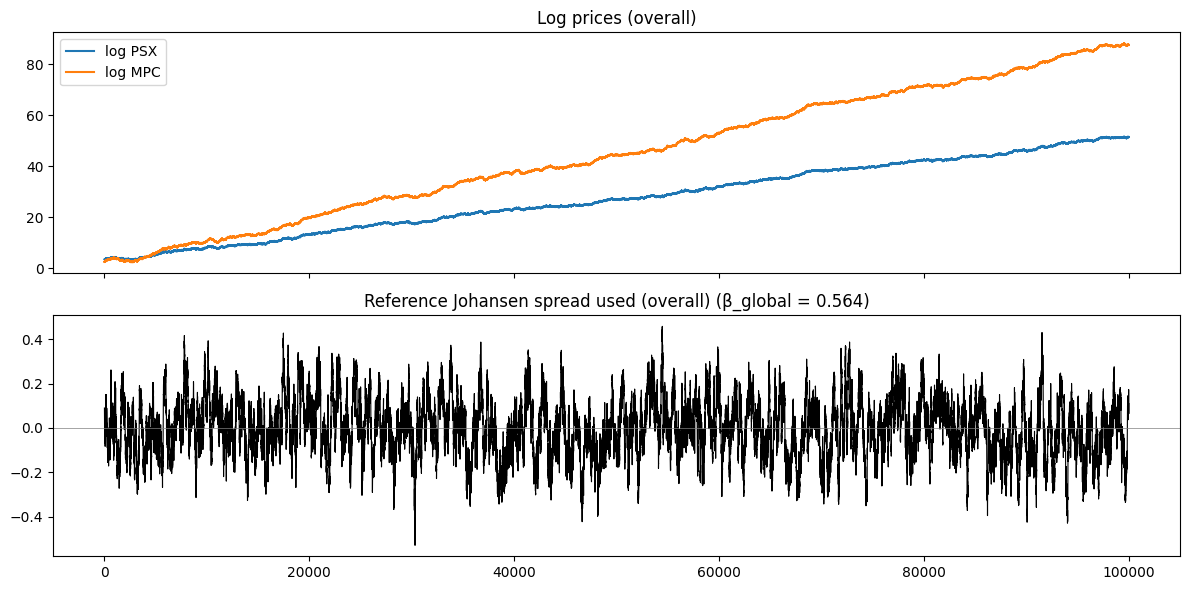

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(s1_synth, label=f'log {ticker_1}'); ax[0].plot(s2_synth, label=f'log {ticker_2}')
ax[0].legend(); ax[0].set_title('Log prices (overall)')
ax[1].plot(spread_synth, color='black', lw=0.8); ax[1].axhline(0, color='grey', lw=0.5)
ax[1].set_title(f'Reference Johansen spread used (overall) (β_global = {beta_const:.3f})')
plt.tight_layout(); plt.show()

### Notes

We see a smooth upwards drift due to (a) constant volatility assumption and (b) drift term becoming very significant for ~100k data points. Hedge ratio / co-integration term has a constant mean + noise, as expected.

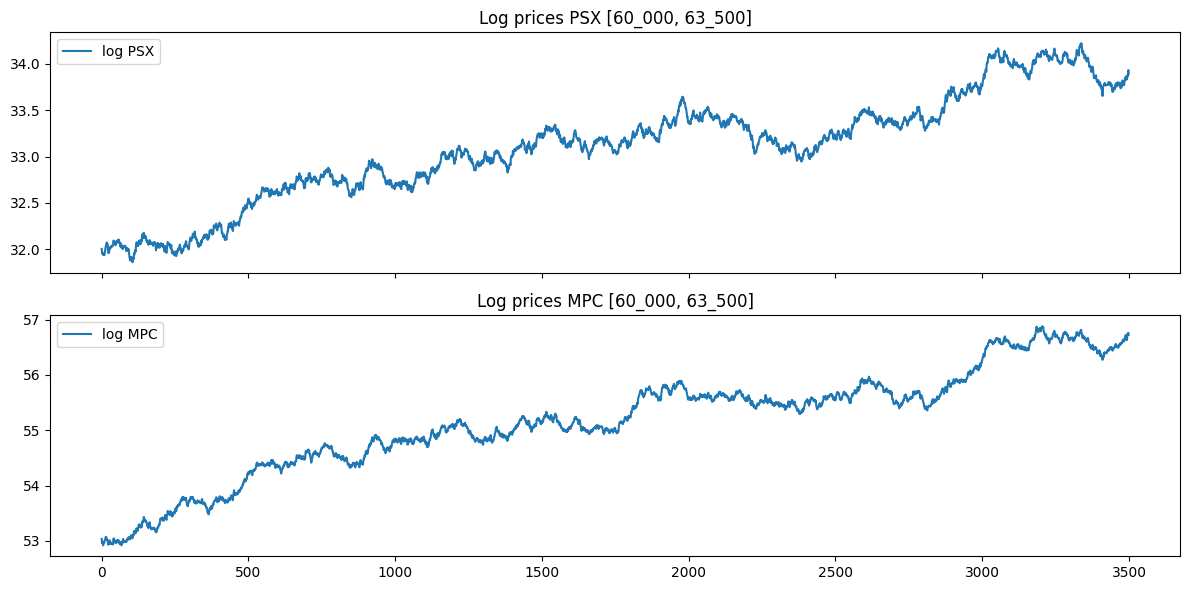

In [26]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(s1_synth[60_000:63_500], label=f'log {ticker_1}')
ax[0].legend(); ax[0].set_title('Log prices PSX [60_000, 63_500]')
ax[1].plot(s2_synth[60_000:63_500], label=f'log {ticker_2}')
ax[1].legend(); ax[1].set_title('Log prices MPC [60_000, 63_500]')
plt.tight_layout(); plt.show()

As we can see above, for each of the two stocks the volatility seems to average out similarly to the historical data (visually), however we don't observe the same volatility spikes.

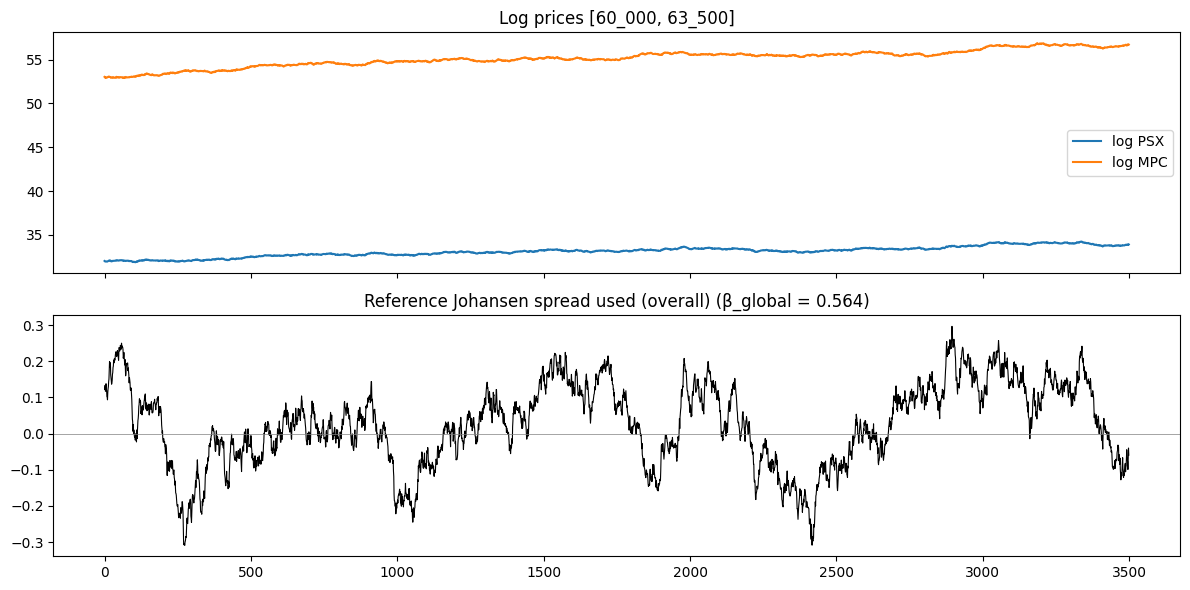

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(s1_synth[60_000:63_500], label=f'log {ticker_1}'); ax[0].plot(s2_synth[60_000:63_500], label=f'log {ticker_2}')
ax[0].legend(); ax[0].set_title('Log prices [60_000, 63_500]')
ax[1].plot(spread_synth[60_000:63_500], color='black', lw=0.8); ax[1].axhline(0, color='grey', lw=0.5)
ax[1].set_title(f'Reference Johansen spread used (overall) (β_global = {beta_const:.3f})')
plt.tight_layout(); plt.show()

Nonetheless, the spread pattern looks quite similar on this chunk of generated data.

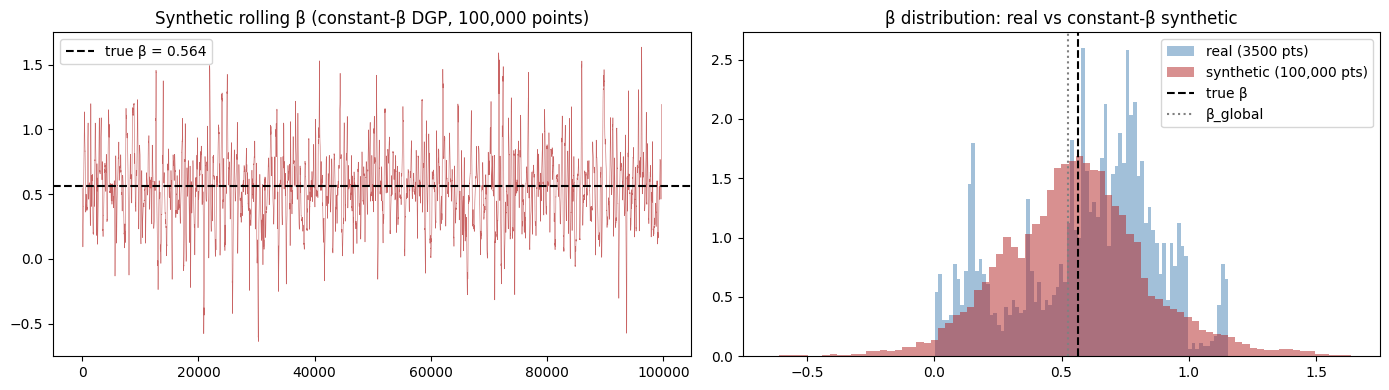

In [28]:
# --- Plots: synthetic rolling β over time + overlaid histograms ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(betas_synth, lw=0.4, color='firebrick', alpha=0.7)
ax[0].axhline(beta_const, color='k', ls='--', label=f'true β = {beta_const:.3f}')
ax[0].set_title(f'Synthetic rolling β (constant-β DGP, {N_sim:,} points)')
ax[0].legend()

ax[1].hist(betas_rolling, bins=80, density=True, alpha=0.5, color='steelblue', label='real (3500 pts)')
ax[1].hist(betas_synth,   bins=80, density=True, alpha=0.5, color='firebrick', label=f'synthetic ({N_sim:,} pts)')
ax[1].axvline(beta_const, color='k', ls='--', label='true β')
ax[1].axvline(beta_global, color='grey', ls=':', label='β_global')
ax[1].set_title('β distribution: real vs constant-β synthetic')
ax[1].legend()
plt.tight_layout(); plt.show()

The synthetic histogram is the rolling-OLS β distribution under the explicit assumption of a constant true β. This looks like a strongly mean-reverting signal with added noise.

We have a superposition of the beta distributions on the right, for both the historical distribution (blue) and the generated distribution (red). The generated distribution clearly converged to a uni-modal normal centered about 0.56, though interestingly, it displays some negative hedge ratios on the left tail, indicating that the co-integration relation flipped.

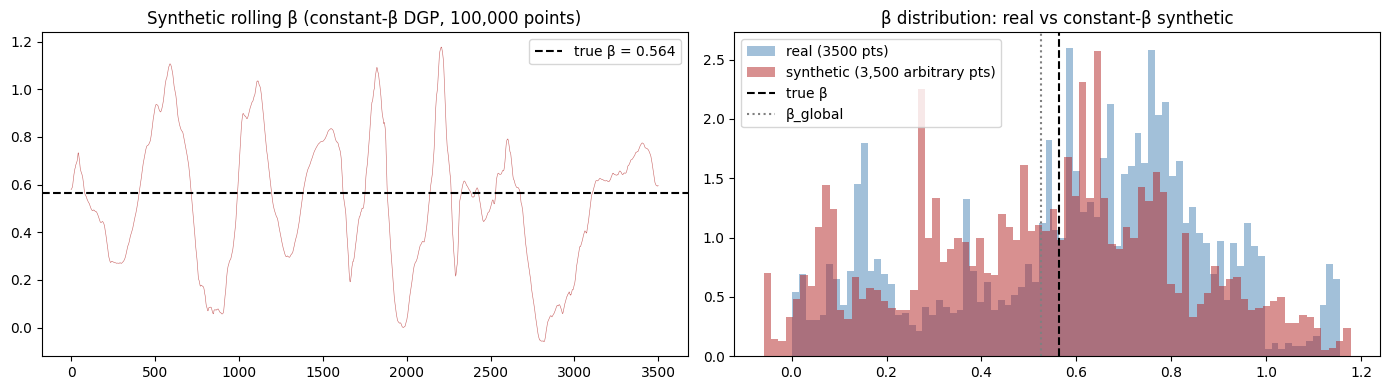

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(betas_synth[82_000:85_500], lw=0.4, color='firebrick', alpha=0.7)
ax[0].axhline(beta_const, color='k', ls='--', label=f'true β = {beta_const:.3f}')
ax[0].set_title(f'Synthetic rolling β (constant-β DGP, {N_sim:,} points)')
ax[0].legend()

ax[1].hist(betas_rolling, bins=80, density=True, alpha=0.5, color='steelblue', label='real (3500 pts)')
ax[1].hist(betas_synth[82_000:85_500],   bins=80, density=True, alpha=0.5, color='firebrick', label=f'synthetic ({3500:,} arbitrary pts)')
ax[1].axvline(beta_const, color='k', ls='--', label='true β')
ax[1].axvline(beta_global, color='grey', ls=':', label='β_global')
ax[1].set_title('β distribution: real vs constant-β synthetic')
ax[1].legend()
plt.tight_layout(); plt.show()

We sampled an arbitrary window of the same size as the historical data (3_500 points) from the generated data. We observe that the distribution of betas at this scale can look multimodal, with clusterings around beta = 0.3 or beta = 0.1, even if the underlying distribution is not itself multi-modal. This means that we cannot immediately conclude from the historical data that there exist multiple regimes, each with an individual beta. Nonetheless, we cannot conclude that the opposite is true either. For this, we'd need:

- More data (10_000, 20_000, 50_000 data points of historical data might be more indicative => maybe we can get to this with hourly candles)
- Different assumptions for volatility / beta: considering them as timed stochastic processes or revising our assumptions for what a regime is.

We can already work with this data as a baseline generator, considering these
limitations, then improve afterwards.

